In [1]:
import rebayes_mini
import jax
jax.config.update("jax_enable_x64", True)
import chex
import numpy as np
import pandas as pd
import seaborn as sns
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
from rebayes_mini import callbacks
from rebayes_mini.states import GaussState
import pickle, os, sys, time, platform
from tqdm import tqdm

from profilter import ExtendedKalmanFilter
from profilter_rebuttal import PrOFilter
from unscented import UnscentedKalmanFilter, UKFPrOFilterPred, CubatureKalmanFilter, CKFPrOFilterPred

cmap = {
    "EKF": "lightseagreen",
    "UKF": "teal",
    "CKF": "slateblue",
    "EKF-PrO": "mediumorchid",
    "UKF-PrO": "deeppink",
    "CKF-PrO": "darkgoldenrod",
}

def euler_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    return y + k1

def rk4_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    k2 = h * f(y + k1 / 2, dt * i + h / 2, i)
    k3 = h * f(y + k2 / 2, t + h / 2, i)
    k4 = h * f(y + k3, t + h, i)

    y_next = y + 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

@partial(jax.jit, static_argnames=("f",))
def solve(ys, dt, N, f):
    @jax.jit
    def step(i, ys):
        ysi = euler_step(ys[i - 1], i, dt, f)
        return ys.at[i].set(ysi)
    return jax.lax.fori_loop(1, N, step, ys)

In [2]:
def get_environment_info():
    return {
        "python_version": sys.version,
        "platform": platform.platform(),
        "processor": platform.processor(),
        "jax_version": jax.__version__,
        "jax_backend": jax.default_backend(),
        "numpy_version": np.__version__,
    }

env_info = get_environment_info()
print(env_info)

{'python_version': '3.11.5 (main, Aug  4 2026, 12:20:09) [Clang 17.0.0 (clang-1700.0.13.5)]', 'platform': 'macOS-15.7.9-x86_64-i386-64bit', 'processor': 'i386', 'jax_version': '0.4.38', 'jax_backend': 'cpu', 'numpy_version': '2.3.5'}


In [3]:
D = 60
N = 1000
dt = 0.002
sigma = 1.0
F = 8.0
n_hidden = 2
transition_prob = 0.995
observation_covariance = 5.0

@partial(jax.vmap, in_axes=(None, 0, None))
def fcoord(x, k, D):
    xdot = (x[(k + 1) % D] - x[k - 2]) * x[k - 1] - x[k] + F
    return xdot

key = jax.random.PRNGKey(315)
key_init, key_sim, key_eval = jax.random.split(key, 3)
key_state, key_measurement = jax.random.split(key_sim)

key_hidden, key_state = jax.random.split(key_state)
transition_state = jnp.ones((n_hidden, n_hidden)) * 1/(n_hidden-1) * (1-transition_prob)
transition_state = transition_state.at[jnp.diag_indices_from(transition_state)].set(transition_prob)

key_hidden, key_state = jax.random.split(key_state)
phi_hidden = jax.random.normal(key_hidden, (D, n_hidden-1)) * sigma
phi_hidden = jnp.concatenate([jnp.zeros((D, 1)), phi_hidden], -1)

@jax.jit
def f(x, t, i, regime):
    keyt = jax.random.fold_in(key_state, i)
    key_regime, keyt = jax.random.split(keyt)
    probabilities = transition_state[regime, :]
    logits = jnp.log(probabilities)
    regime_next = jax.random.categorical(key_regime, logits)
    ixs = jnp.arange(D)
    xdot = fcoord(x, ixs, D) + phi_hidden[:, regime_next]
    return xdot, regime_next

x0 = jax.random.normal(key_init, (D,))
x_init = jnp.copy(x0)
xs = jnp.zeros((N,) + x0.shape)
xs = xs.at[0].set(x0)
regime = int(0)
for i in range(1, N):
    xdot, regime = f(x0, i * dt, i, regime)
    x0 = x0 + dt * xdot
    xs = xs.at[i].set(x0)

ys = xs + jnp.sqrt(observation_covariance) * jax.random.normal(key_measurement, xs.shape)

def latent_fn(x):
    @jax.jit
    def f(x, t, _):
        ixs = jnp.arange(D)
        return fcoord(x, ixs, D)
    return euler_step(x, 0, dt, f)

def obs_fn(x, _):
    return x

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

errs = {}
mses = {}
nlls = {}
times = {}

In [4]:
from unscented import UKFPrOFilterPred
method = "UKF-PrO"

nsteps = xs.shape[0]
t0 = time.time()
agent_ukfpro = UKFPrOFilterPred(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        n_inner=5, n_outer=10,
    )

init_bel = agent_ukfpro.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ukfpro.scan, callback_fn=get_mean_and_cov)
_, (hist1, hist1_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))
hist1.block_until_ready()
hist1_cov.block_until_ready()
times[method] = time.time() - t0

err = jnp.sqrt(jnp.sum(jnp.square(hist1 - xs), -1))
errs[method] = err

mse = jnp.sum(jnp.square(hist1-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist1, hist1_cov)
nlls[method] = nll_per_step

print(f"{method}: mean error = {jnp.mean(err):.4f}, MSE = {mse:.4f}, mean NLL = {jnp.mean(nll_per_step):.4f}, time = {times[method]:.1f}s")

UKF-PrO: mean error = 2.2078, MSE = 5074.2504, mean NLL = 609.1328, time = 29.8s


In [5]:
from unscented import UKFPrOFilter
method = "UKF-PrO+"

nsteps = xs.shape[0]
t0 = time.time()
agent_ukfprofull = UKFPrOFilter(
        latent_fn, obs_fn,
        dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
        observation_covariance=observation_covariance * jnp.eye(D),
        n_inner=5, n_outer=10,
    )

init_bel = agent_ukfprofull.init_bel(x_init, cov=1.0)
filterfn = partial(agent_ukfprofull.scan, callback_fn=get_mean_and_cov)
_, (hist2, hist2_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))
hist2.block_until_ready()
hist2_cov.block_until_ready()
times[method] = time.time() - t0

err = jnp.sqrt(jnp.sum(jnp.square(hist2 - xs), -1))
errs[method] = err

mse = jnp.sum(jnp.square(hist2-xs))
mses[method] = mse

nll_per_step = jax.vmap(nll_step)(xs, hist2, hist2_cov)
nlls[method] = nll_per_step

print(f"{method}: mean error = {jnp.mean(err):.4f}, MSE = {mse:.4f}, mean NLL = {jnp.mean(nll_per_step):.4f}, time = {times[method]:.1f}s")

UKF-PrO+: mean error = 2.3284, MSE = 5659.4602, mean NLL = 646.1815, time = 332.7s


In [6]:
results = {
    "errs": {m: np.array(errs[m]) for m in errs},
    "mses": {m: float(mses[m]) for m in mses},
    "nlls": {m: np.array(nlls[m]) for m in nlls},
    "times": times,
    "environment": env_info,
}
pickle.dump(results, open("full_update_identity_h_results.pkl", "wb"))
print("Saved.")

Saved.


/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_53194/941309559.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap_full, order=methods)
/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_53194/941309559.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap_full, order=methods)


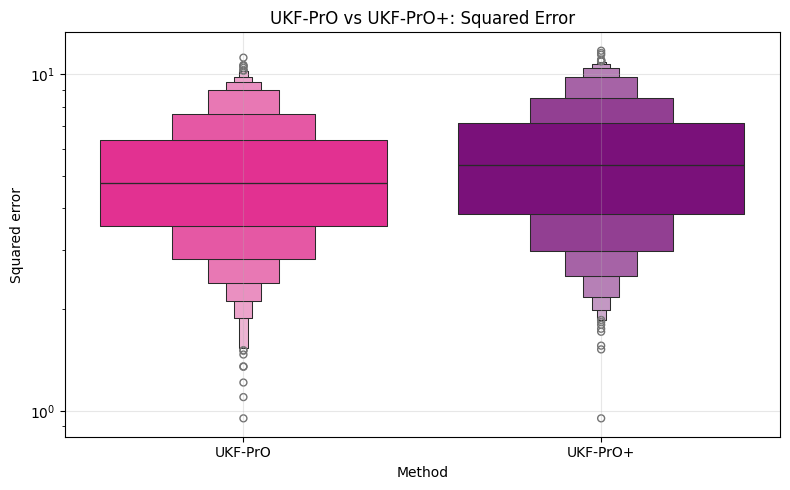

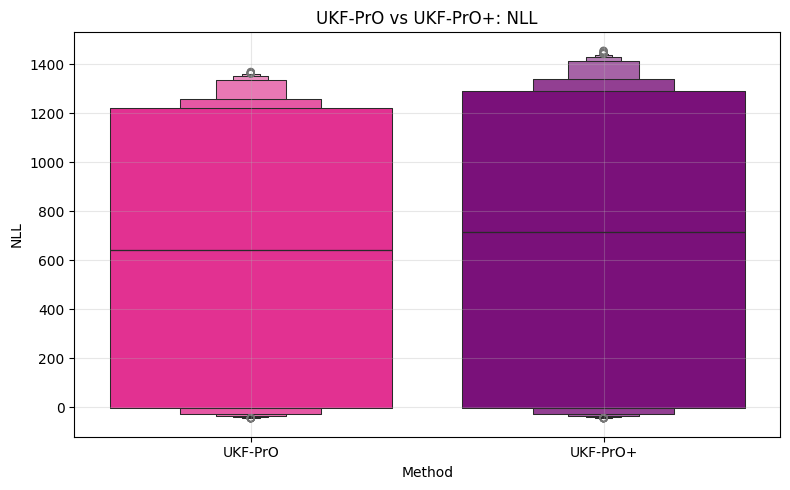

In [7]:
methods = ["UKF-PrO", "UKF-PrO+"]

mse_rows = []
nll_rows = []
for m in methods:
    for t, (e, n) in enumerate(zip(errs[m]**2, nlls[m])):
        mse_rows.append({"method": m, "step": t, "error": float(e)})
        nll_rows.append({"method": m, "step": t, "error": float(n)})

mse_df = pd.DataFrame(mse_rows)
nll_df = pd.DataFrame(nll_rows)

cmap_full = {
    "UKF-PrO": "deeppink",
    "UKF-PrO+": "darkmagenta",
}

plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap_full, order=methods)
plt.xlabel("Method")
plt.ylabel("Squared error")
plt.grid(alpha=0.3)
plt.yscale("log")
plt.title("UKF-PrO vs UKF-PrO+: Squared Error")
plt.tight_layout()
plt.savefig("full_update_mse.pdf")
mse_df.to_csv("full_update_mse.csv", index=False)

plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap_full, order=methods)
plt.xlabel("Method")
plt.ylabel("NLL")
plt.grid(alpha=0.3)
plt.title("UKF-PrO vs UKF-PrO+: NLL")
plt.tight_layout()
plt.savefig("full_update_nll.pdf")
nll_df.to_csv("full_update_nll.csv", index=False)